In [9]:
import numpy as np
import scipy.linalg as la
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def generate_wilkinson(N):
    
    # Create the main diagonal: |(N-1)/2 - i|
    diag = np.abs(np.arange(N) - (N - 1) / 2.0)
    
    # Create the off-diagonal of 1s
    off_diag = np.ones(N - 1)
    
    # Assemble the dense symmetric matrix
    return np.diag(diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)


In [4]:
sizes = [50, 100, 250, 500, 1000, 1500, 2000]
drivers = {'Shifted QR (ev)': 'ev', 'Divide & Conquer (evd)': 'evd', 'MRRR (evr)': 'evr'}

results = []

for N in sizes:
    print(f"Generating and Solving Wilkinson Matrix: {N}x{N}...")
    A = generate_wilkinson(N)
    norm_A = la.norm(A, 2)
    
    for name, driver in drivers.items():
        start = time.perf_counter()
        evals, evecs = la.eigh(A, driver=driver)
        run_time = time.perf_counter() - start
        
        # 1. Calculate Average Relative Residual Norm
        residuals = []
        for i in range(len(evals)):
            v = evecs[:, i]
            lam = evals[i]
            res = la.norm(A @ v - lam * v, 2) / (norm_A * la.norm(v, 2))
            residuals.append(res)
        avg_res = np.mean(residuals)
        
        # 2. Calculate Orthogonal Loss (||V^T V - I||_F)
        I = np.eye(N)
        ortho_loss = la.norm(evecs.T @ evecs - I, 'fro')
        
        results.append({
            'Solver Algorithm': name,
            'Matrix Size': N,
            'Execution Runtime (s)': run_time,
            'Average Residual Norm': avg_res,
            'Orthogonal Loss': ortho_loss
        })

print("\nBenchmarking Complete!")

Generating and Solving Wilkinson Matrix: 50x50...
Generating and Solving Wilkinson Matrix: 100x100...
Generating and Solving Wilkinson Matrix: 250x250...
Generating and Solving Wilkinson Matrix: 500x500...
Generating and Solving Wilkinson Matrix: 1000x1000...
Generating and Solving Wilkinson Matrix: 1500x1500...
Generating and Solving Wilkinson Matrix: 2000x2000...

Benchmarking Complete!


In [10]:
df_wilkinson = pd.DataFrame(results)

display(df_wilkinson)

,Solver Algorithm,Matrix Size,Execution Runtime (s),Average Residual Norm,Orthogonal Loss
0,Shifted QR (ev),50,0.007057,4.602339e-16,1.177263e-14
1,Divide & Conquer (evd),50,0.002713,2.222789e-16,7.016623e-15
2,MRRR (evr),50,0.002419,5.593333e-16,3.212242e-13
3,Shifted QR (ev),100,0.001811,5.606797e-16,2.317302e-14
4,Divide & Conquer (evd),100,0.003974,1.669483e-16,1.234388e-14
5,MRRR (evr),100,0.004301,5.411550e-16,2.260307e-14
6,Shifted QR (ev),250,0.034146,5.347636e-16,5.856569e-14
7,Divide & Conquer (evd),250,0.005071,1.933173e-16,1.625539e-14
8,MRRR (evr),250,0.025952,5.214457e-16,1.242990e-13
9,Shifted QR (ev),500,0.143660,6.387042e-16,1.081761e-13


# Save to your processed data folder
df_wilkinson.to_csv('results_wilkinson_matrix.csv', index=False)

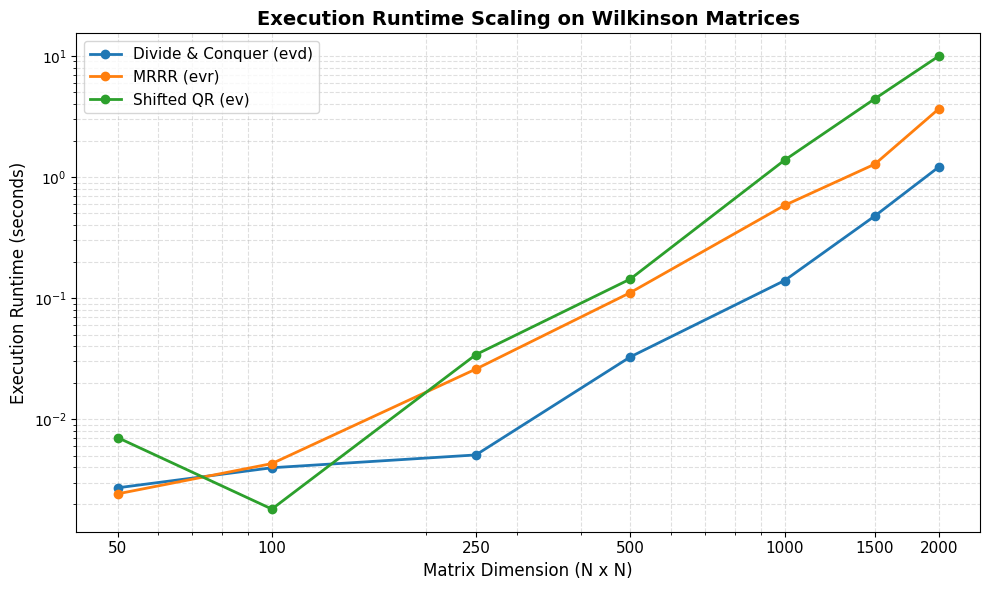

In [7]:
plt.figure(figsize=(10, 6))

for algorithm, group in df_wilkinson.groupby('Solver Algorithm'):
    plt.plot(group['Matrix Size'], group['Execution Runtime (s)'], marker='o', linewidth=2, label=algorithm)

plt.xscale('log')
plt.yscale('log')
plt.xticks(sizes, [str(s) for s in sizes], fontsize=11)

plt.xlabel('Matrix Dimension (N x N)', fontsize=12)
plt.ylabel('Execution Runtime (seconds)', fontsize=12)
plt.title('Execution Runtime Scaling on Wilkinson Matrices', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

- Divide & Conquer (evd): This is the fastest algorithm for large matrices. At a matrix dimension of $2000 \times 2000$, it completes in roughly $10^0$ (1 second).
- MRRR (evr): This algorithm is the second fastest for large matrices. At $N=2000$, its execution runtime is slightly below $10^{0.5}$, taking approximately 3 to 4 seconds.
- Shifted QR (ev): This is the slowest algorithm as the matrix dimension scales. At $N=2000$, the runtime hits exactly $10^1$, taking 10 seconds to execute.

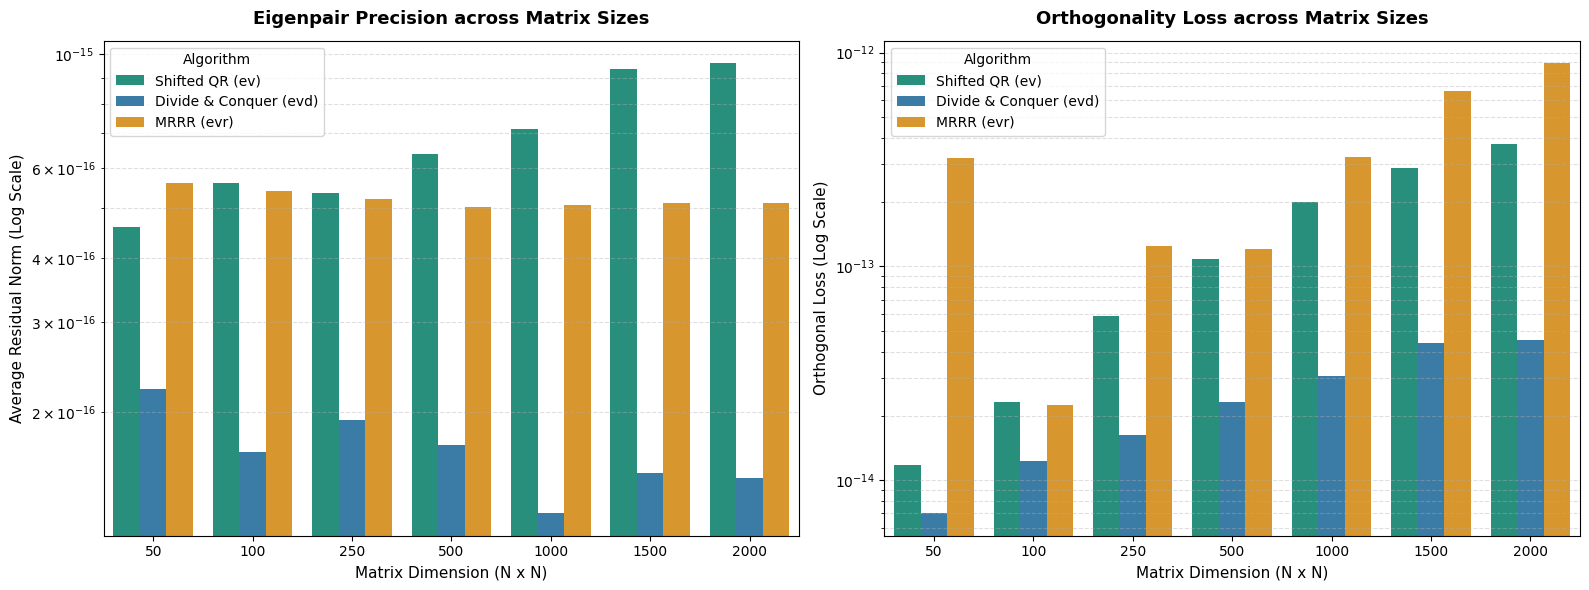

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
custom_palette = ['#16a085', '#2980b9', '#f39c12']

# 1. Grouped Bar Plot: Residual Norm
sns.barplot(
    data=df_wilkinson, 
    x='Matrix Size', 
    y='Average Residual Norm', 
    hue='Solver Algorithm', 
    ax=ax[0], 
    palette=custom_palette
)
ax[0].set_yscale('log')
ax[0].set_title('Eigenpair Precision across Matrix Sizes', fontsize=13, fontweight='bold', pad=12)
ax[0].set_ylabel('Average Residual Norm (Log Scale)', fontsize=11)
ax[0].set_xlabel('Matrix Dimension (N x N)', fontsize=11)
ax[0].legend(title='Algorithm', fontsize=10)
ax[0].grid(True, which="both", ls="--", alpha=0.4, axis='y')

# 2. Grouped Bar Plot: Orthogonal Loss
sns.barplot(
    data=df_wilkinson, 
    x='Matrix Size', 
    y='Orthogonal Loss', 
    hue='Solver Algorithm', 
    ax=ax[1], 
    palette=custom_palette
)
ax[1].set_yscale('log')
ax[1].set_title('Orthogonality Loss across Matrix Sizes', fontsize=13, fontweight='bold', pad=12)
ax[1].set_ylabel('Orthogonal Loss (Log Scale)', fontsize=11)
ax[1].set_xlabel('Matrix Dimension (N x N)', fontsize=11)
ax[1].legend(title='Algorithm', fontsize=10)
ax[1].grid(True, which="both", ls="--", alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

#### Eigenpair Precision (Left Chart):
- Divide & Conquer (evd) demonstrates the highest precision (lowest residual norm) as matrix sizes increase, dropping close to $10^{-16}$ at $N=2000$.- MRRR (evr) maintains a highly stable residual norm across all matrix dimensions, hovering steadily around $5 \times 10^{-16}$.
- Shifted QR (ev) shows the highest average residual norm for the largest matrices, approaching $10^{-15}$ at $N=2000$.

#### Eigenvector Orthogonality Loss (Right Chart):
- Divide & Conquer (evd) consistently maintains the lowest orthogonality loss, staying well below $10^{-13}$ across all tested dimensions.
- Shifted QR (ev) falls in the middle for large matrices, ending at approximately $3 \times 10^{-13}$ for $N=2000$.
- MRRR (evr) exhibits the highest orthogonality loss among the three solvers, scaling up to just under $10^{-12}$ at $N=2000$.

### Final Conclusion 
- Scalability & Speed Efficiency:On symmetric tridiagonal synthetic matrices ranging from $50 \times 50$ to $2000 \times 2000$, Divide & Conquer (evd) is the fastest and most scalable algorithm. It outperforms MRRR (evr) and is a full order of magnitude faster (1 second vs. 10 seconds) than Shifted QR (ev) at $N = 2000$.
- Numerical Accuracy:While all algorithms maintain excellent precision, Divide & Conquer (evd) achieves the lowest relative residual errors for large matrices. MRRR (evr) provides the most consistent precision regardless of matrix size.
- Orthogonality Trade-off:Divide & Conquer (evd) preserves the tightest eigenvector orthogonality across all dimensions. MRRR (evr) trades off some orthogonality, reaching just under $10^{-12}$ at $N=2000$, which is the highest loss among the three solvers but remains tightly bounded.